# Modeling notebook

LendingClub default prediction for the capstone DSS experiment.

**Objective:** fit and calibrate candidate models under the locked temporal split, then export the official build artifacts used for case selection.

**Inference rule:** validation is used for calibration choice and model comparison. The post-2016 test set is evaluated only after the final model choice is locked.

The EDA notebook defines the feature set, difficulty construction, and processed dataset, while this notebook treats those decisions as fixed and focuses on calibrated default prediction.

In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.base import clone
from scipy.stats import ttest_rel
from xgboost import XGBClassifier

try:
    from sklearn.frozen import FrozenEstimator
    HAS_FROZEN_ESTIMATOR = True
except ImportError:
    FrozenEstimator = None
    HAS_FROZEN_ESTIMATOR = False


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / 'artifacts').exists() and (candidate / 'codes').exists():
            return candidate
    raise RuntimeError('Could not locate repository root. Run from inside the capstone repo.')


# Paths
ROOT = find_repo_root()
DATA_PROC = ROOT / 'data' / 'processed' / 'loan_v1.csv'
ARTIFACTS = ROOT / 'artifacts'
BUILD_DIR = ARTIFACTS / 'build'
FIGS_DIR = ROOT / 'codes' / 'visualizations'

BUILD_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT / 'codes') not in sys.path:
    sys.path.append(str(ROOT / 'codes'))

from feature_config import FEATURES, NUM_COLS, CAT_COLS, TARGET

np.random.seed(42)
pd.set_option('display.max_columns', None)

print('ROOT     :', ROOT)
print('BUILD_DIR:', BUILD_DIR)
print('FIGS_DIR :', FIGS_DIR)
print('Working  :', Path.cwd())

ROOT     : /Users/annaasatryan/Desktop/capstone
BUILD_DIR: /Users/annaasatryan/Desktop/capstone/artifacts/build
FIGS_DIR : /Users/annaasatryan/Desktop/capstone/codes/visualizations
Working  : /Users/annaasatryan/Desktop/capstone/codes/notebooks


## Data loading

The processed dataset is the output of the EDA/data-preparation notebook. It already contains the final feature set, target, issue date, deterministic `case_id`, and train-derived difficulty fields.

In [2]:
df = pd.read_csv(DATA_PROC)
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

print('Shape:', df.shape)
print('Default rate:', round(df[TARGET].mean(), 4))
print('Date range:', df['issue_d'].min(), '→', df['issue_d'].max())
print('\nFeatures used:', FEATURES)

Shape: (1298960, 15)
Default rate: 0.2008
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00

Features used: ['loan_amnt', 'term', 'int_rate', 'dti', 'revol_util', 'home_ownership', 'purpose', 'log_annual_inc', 'credit_history_years']


## Temporal splits

Split strategy:

- `train`: chronological 70% of pre-2016 observations; used for base model fitting
- `cal`: first half of the remaining 30% of pre-2016 observations; used for calibration only
- `val`: second half of the remaining 30% of pre-2016 observations; used for calibration-method comparison and model comparison
- `test`: post-2016 observations; used once for final reporting after the final model is fixed

Calibration is isolated from validation to prevent isotonic regression from memorizing the set used to evaluate calibration. Model choice is based on validation behavior, not test performance.

In [3]:
split_date = pd.Timestamp('2016-01-01')

train_full = df[df['issue_d'] < split_date].copy()
test = df[df['issue_d'] >= split_date].copy()

cutoff_cal = train_full['issue_d'].quantile(0.70)
train = train_full[train_full['issue_d'] < cutoff_cal].copy()
cal_val = train_full[train_full['issue_d'] >= cutoff_cal].copy()

cutoff_val = cal_val['issue_d'].quantile(0.50)
cal = cal_val[cal_val['issue_d'] < cutoff_val].copy()
val = cal_val[cal_val['issue_d'] >= cutoff_val].copy()

y_train = train[TARGET].copy()
y_cal = cal[TARGET].copy()
y_val = val[TARGET].copy()
y_test = test[TARGET].copy()

# Features only for modeling
# case_id and difficulty fields are kept outside X to avoid accidental leakage
X_train = train[FEATURES].copy()
X_cal = cal[FEATURES].copy()
X_val = val[FEATURES].copy()
X_test = test[FEATURES].copy()

# case_id is retained only for final export
case_id_train = train['case_id'].copy()
case_id_cal = cal['case_id'].copy()
case_id_val = val['case_id'].copy()
case_id_test = test['case_id'].copy()

print(f'Train: {train.shape[0]:>8,} | default rate: {y_train.mean():.4f}')
print(f'Cal  : {cal.shape[0]:>8,} | default rate: {y_cal.mean():.4f}')
print(f'Val  : {val.shape[0]:>8,} | default rate: {y_val.mean():.4f}')
print(f'Test : {test.shape[0]:>8,} | default rate: {y_test.mean():.4f}')

Train:  554,109 | default rate: 0.1765
Cal  :  126,135 | default rate: 0.2031
Val  :  138,972 | default rate: 0.1995
Test :  479,744 | default rate: 0.2288


## Outlier capping: train-derived

DTI has extreme outliers. The cap is estimated from the training set only, then applied unchanged to calibration, validation, and test. This preserves the no-leakage rule while preventing a few extreme values from dominating standardized numeric features.

In [4]:
dti_upper = X_train['dti'].quantile(0.999)

for X in [X_train, X_cal, X_val, X_test]:
    X['dti'] = X['dti'].clip(upper=dti_upper)

print(f'DTI clipped at {dti_upper:.2f} using train 99.9th percentile')

DTI clipped at 39.53 using train 99.9th percentile


## Preprocessing pipeline

Numeric features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding with the first level dropped.

The preprocessing object is embedded inside each model pipeline so that all transformations are fitted only on the relevant training fold/sample.

In [ ]:
def make_onehot_encoder():
    # sparse_output was introduced in newer sklearn versions
    # The fallback keeps the notebook runnable on older environments
    try:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)


preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            NUM_COLS,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', make_onehot_encoder()),
            ]),
            CAT_COLS,
        ),
    ]
)

## Metric functions

Metrics:

- **AUC**: rank discrimination
- **Brier score**: squared-error calibration and probability quality; lower is better
- **Log loss**: likelihood-based probability quality; lower is better
- **ECE**: expected calibration error

ECE uses fixed equal-width bins. Fixed bins make ECE comparable across models, time periods, and difficulty tiers. Quantile bins would change with each distribution and make cross-subset comparison less interpretable.

In [ ]:
def compute_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i + 1])

        if mask.sum() == 0:
            continue

        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return ece


def evaluate(y_true, y_prob, label=''):
    return {
        'Model': label,
        'AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Brier': round(brier_score_loss(y_true, y_prob), 4),
        'LogLoss': round(log_loss(y_true, y_prob), 4),
        'ECE': round(compute_ece(y_true, y_prob), 4),
    }


# Bootstrap uses a fixed seed for reproducible confidence intervals
def bootstrap_ci(y_true, y_prob, metric_fn, n=1000, alpha=0.05, seed=42):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    rng = np.random.default_rng(seed)
    N = len(y_true)
    vals = []

    for _ in range(n):
        idx = rng.choice(N, N, replace=True)
        vals.append(metric_fn(y_true[idx], y_prob[idx]))

    lo = round(np.percentile(vals, 100 * alpha / 2), 4)
    hi = round(np.percentile(vals, 100 * (1 - alpha / 2)), 4)
    return lo, hi

## Model definitions

Three candidate models are evaluated:

- **Logistic Regression**: interpretable baseline and preferred DSS candidate
- **XGBoost**: tree-boosting benchmark
- **Histogram Gradient Boosting**: sklearn-native boosting benchmark

Hyperparameters are fixed rather than grid-searched. The goal is a defensible, calibrated DSS model for a human-AI experiment, not maximum leaderboard performance.

In [7]:
models = {
    'Logistic': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=0.1,
            max_iter=3000,
            random_state=42,
        )),
    ]),

    'XGB': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            verbosity=0,
        )),
    ]),

    'HGB': Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=300,
            max_depth=4,
            learning_rate=0.05,
            random_state=42,
        )),
    ]),
}

## Calibration helper

The base estimator is fitted first, then frozen for calibration. This avoids refitting the base model inside `CalibratedClassifierCV`.

`FrozenEstimator` is used when available. The `cv='prefit'` fallback keeps the notebook compatible with older scikit-learn versions.

In [ ]:
def calibrate_prefit_model(pipe, X_cal, y_cal, method):
    """Calibrate an already-fitted model without re-fitting the base estimator."""
    if HAS_FROZEN_ESTIMATOR:
        calibrated = CalibratedClassifierCV(
            estimator=FrozenEstimator(pipe),
            method=method,
        )
    else:
        calibrated = CalibratedClassifierCV(
            estimator=pipe,
            method=method,
            cv='prefit',
        )

    calibrated.fit(X_cal, y_cal)
    return calibrated


def get_base_pipeline(calibrated_model):
    """Recover the fitted base pipeline from a calibrated classifier."""
    calibrated_clf = calibrated_model.calibrated_classifiers_[0]
    estimator = getattr(calibrated_clf, 'estimator', None)

    # Newer sklearn may store a FrozenEstimator wrapper
    if hasattr(estimator, 'estimator'):
        return estimator.estimator
    if hasattr(estimator, 'estimator_'):
        return estimator.estimator_

    return estimator

## Resampled training stability analysis

This section checks whether model comparisons are stable under resampling of the training data.

Stability is evaluated on the **validation set**, not the test set. The test set remains reserved for final reporting only.

Procedure:

1. Bootstrap sample the training set only.
2. Fit each base model on the bootstrapped training sample.
3. Calibrate on the fixed calibration split.
4. Select isotonic vs sigmoid calibration by validation Brier score.
5. Record validation AUC, Brier, and ECE.

In [9]:
N_RUNS = 10
rng = np.random.default_rng(42)
records = []

for run in range(N_RUNS):
    print(f'\n=== BOOTSTRAP RUN {run + 1}/{N_RUNS} ===')

    # 1. Bootstrap sample: train only
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    X_train_boot = X_train.iloc[idx].copy()
    y_train_boot = y_train.iloc[idx].copy()

    for name, base_pipe in models.items():
        # 2. Fit a fresh model on the bootstrapped sample
        pipe = clone(base_pipe)
        pipe.fit(X_train_boot, y_train_boot)

        # 3. Calibrate the fitted model on the calibration split
        iso = calibrate_prefit_model(pipe, X_cal, y_cal, method='isotonic')
        sig = calibrate_prefit_model(pipe, X_cal, y_cal, method='sigmoid')

        # 4. Select calibration method using validation Brier score
        probs_val_iso = iso.predict_proba(X_val)[:, 1]
        probs_val_sig = sig.predict_proba(X_val)[:, 1]

        brier_iso = brier_score_loss(y_val, probs_val_iso)
        brier_sig = brier_score_loss(y_val, probs_val_sig)

        if brier_iso < brier_sig:
            chosen_method = 'isotonic'
            probs_val = probs_val_iso
        else:
            chosen_method = 'sigmoid'
            probs_val = probs_val_sig

        # 5. Evaluate on validation only
        records.append({
            'run': run,
            'model': name,
            'chosen_calibration': chosen_method,
            'AUC': roc_auc_score(y_val, probs_val),
            'Brier': brier_score_loss(y_val, probs_val),
            'ECE': compute_ece(y_val, probs_val),
        })

robust_df = pd.DataFrame(records)

print('\n=== ROBUSTNESS SUMMARY — VALIDATION SET ===\n')
summary = robust_df.groupby('model')[['AUC', 'Brier', 'ECE']].agg(['mean', 'std'])
print(summary)


=== BOOTSTRAP RUN 1/10 ===

=== BOOTSTRAP RUN 2/10 ===

=== BOOTSTRAP RUN 3/10 ===

=== BOOTSTRAP RUN 4/10 ===

=== BOOTSTRAP RUN 5/10 ===

=== BOOTSTRAP RUN 6/10 ===

=== BOOTSTRAP RUN 7/10 ===

=== BOOTSTRAP RUN 8/10 ===

=== BOOTSTRAP RUN 9/10 ===

=== BOOTSTRAP RUN 10/10 ===

=== ROBUSTNESS SUMMARY — VALIDATION SET ===

               AUC               Brier                 ECE          
              mean       std      mean       std      mean       std
model                                                               
HGB       0.731487  0.000339  0.141251  0.000070  0.008755  0.000467
Logistic  0.726480  0.000298  0.141921  0.000033  0.007918  0.000107
XGB       0.731105  0.000412  0.141361  0.000075  0.010271  0.000292


## Statistical comparison on validation resamples

Paired tests compare models across the same bootstrap runs. This provides a stability diagnostic.

Because the dataset is large, small metric differences can be statistically detectable while remaining practically negligible. Practical size and interpretability matter for the DSS experiment.

In [10]:
def paired_test(df_source, m1, m2, metric):
    x = df_source[df_source['model'] == m1].sort_values('run')[metric].values
    y = df_source[df_source['model'] == m2].sort_values('run')[metric].values

    stat, p = ttest_rel(x, y)
    diff = x - y

    print(f'\n{m1} vs {m2} ({metric})')
    print(f'Mean difference: {diff.mean():.6f}')
    print(f'Std difference : {diff.std(ddof=1):.6f}')
    print(f't-stat         : {stat:.4f}')
    print(f'p-value        : {p:.6f}')


paired_test(robust_df, 'Logistic', 'XGB', 'Brier')
paired_test(robust_df, 'Logistic', 'HGB', 'Brier')
paired_test(robust_df, 'HGB', 'XGB', 'Brier')


Logistic vs XGB (Brier)
Mean difference: 0.000560
Std difference : 0.000076
t-stat         : 23.4401
p-value        : 0.000000

Logistic vs HGB (Brier)
Mean difference: 0.000670
Std difference : 0.000079
t-stat         : 26.7867
p-value        : 0.000000

HGB vs XGB (Brier)
Mean difference: -0.000110
Std difference : 0.000041
t-stat         : -8.4460
p-value        : 0.000014


Model comparison across logistic regression, XGBoost, and histogram gradient boosting is used to assess whether a more complex model materially improves calibrated probability quality.

The final model is not selected by test performance. Logistic regression can be fixed as the final model when validation differences are small enough that interpretability and experimental clarity dominate.

## Train and calibrate all models

Pipeline:

1. Fit the base model on `X_train`.
2. Fit isotonic and sigmoid calibration on `X_cal` using the frozen fitted model.
3. Select calibration method using **validation Brier** within each model class.
4. Store validation predictions and validation Brier for model comparison.
5. Do not compute test predictions in this step.

In [11]:
trained = {}

for name, base_pipe in models.items():
    print(f'\nTraining {name}...')

    # 1. Fit base model
    pipe = clone(base_pipe)
    pipe.fit(X_train, y_train)

    # 2. Fit calibration models on calibration split
    iso = calibrate_prefit_model(pipe, X_cal, y_cal, method='isotonic')
    sig = calibrate_prefit_model(pipe, X_cal, y_cal, method='sigmoid')

    # 3. Validation predictions
    probs_val_iso = iso.predict_proba(X_val)[:, 1]
    probs_val_sig = sig.predict_proba(X_val)[:, 1]

    # 4. Select calibration via validation Brier score
    brier_iso_val = brier_score_loss(y_val, probs_val_iso)
    brier_sig_val = brier_score_loss(y_val, probs_val_sig)

    if brier_iso_val < brier_sig_val:
        chosen = iso
        method = 'isotonic'
        probs_val = probs_val_iso
    else:
        chosen = sig
        method = 'sigmoid'
        probs_val = probs_val_sig

    # Diagnostics shown for transparency
    ece_iso_val = compute_ece(y_val, probs_val_iso)
    ece_sig_val = compute_ece(y_val, probs_val_sig)
    val_brier = brier_score_loss(y_val, probs_val)

    trained[name] = {
        'model': chosen,
        'probs_val': probs_val,
        'val_brier': val_brier,
        'cal_method': method,
    }

    print(f'Calibration: {method}')
    print(f'Val Brier : iso={brier_iso_val:.4f} | sig={brier_sig_val:.4f}')
    print(f'Val ECE   : iso={ece_iso_val:.4f} | sig={ece_sig_val:.4f}')

print('\nAll models trained and calibrated.')


Training Logistic...
Calibration: isotonic
Val Brier : iso=0.1419 | sig=0.1420
Val ECE   : iso=0.0080 | sig=0.0123

Training XGB...
Calibration: isotonic
Val Brier : iso=0.1413 | sig=0.1423
Val ECE   : iso=0.0105 | sig=0.0284

Training HGB...
Calibration: sigmoid
Val Brier : iso=0.1412 | sig=0.1411
Val ECE   : iso=0.0086 | sig=0.0085

All models trained and calibrated.


## Model selection

Validation Brier is computed for all three models for comparison.

The final model is fixed as logistic regression when differences are practically negligible because:

- coefficients are directly readable as log-odds
- the model is stable and transparent
- a simpler model avoids confounding participant behavior with unnecessary model complexity
- the experiment studies human-AI interaction, not maximum predictive performance

Test-set metrics below are final reporting diagnostics only. They are not used to select or tune the model.

In [12]:
val_briers = {name: d['val_brier'] for name, d in trained.items()}

print('=== VALIDATION BRIER — MODEL COMPARISON ===\n')
for name, brier in val_briers.items():
    print(f'{name:10s}: {brier:.4f}')

# Fixed final model for interpretability and DSS experimental clarity
FINAL_MODEL_NAME = 'Logistic'
final_model = trained[FINAL_MODEL_NAME]['model']

print(f'\nSelected: {FINAL_MODEL_NAME}')
print('Reason: fixed for interpretability, experimental clarity, and small validation-performance differences.')

=== VALIDATION BRIER — MODEL COMPARISON ===

Logistic  : 0.1419
XGB       : 0.1413
HGB       : 0.1411

Selected: Logistic
Reason: fixed for interpretability, experimental clarity, and small validation-performance differences.


## Final test evaluation

The test set is evaluated only after the final model has been fixed. This cell computes final reporting metrics and confidence intervals.

In [13]:
for name, d in trained.items():
    d['probs_test'] = d['model'].predict_proba(X_test)[:, 1]

final_probs = trained[FINAL_MODEL_NAME]['probs_test']

results = []

for name, d in trained.items():
    m = evaluate(y_test, d['probs_test'], label=name)
    m['Calibration'] = d['cal_method']
    m['Val_Brier'] = round(d['val_brier'], 4)

    auc_lo, auc_hi = bootstrap_ci(y_test.values, d['probs_test'], roc_auc_score)
    brier_lo, brier_hi = bootstrap_ci(y_test.values, d['probs_test'], brier_score_loss)

    m['AUC_95CI'] = f'[{auc_lo}, {auc_hi}]'
    m['Brier_95CI'] = f'[{brier_lo}, {brier_hi}]'

    results.append(m)

results_df = pd.DataFrame(results).set_index('Model')

print('\n=== MODEL COMPARISON — TEST SET FINAL REPORTING ===\n')
print(
    results_df[
        [
            'AUC',
            'Brier',
            'LogLoss',
            'ECE',
            'Calibration',
            'Val_Brier',
            'AUC_95CI',
            'Brier_95CI',
        ]
    ].to_string()
)

print('\n=== EFFECT SIZE — TEST BRIER DIFFERENCES ===')
for other in ['HGB', 'XGB']:
    if other in results_df.index:
        delta = results_df.loc[FINAL_MODEL_NAME, 'Brier'] - results_df.loc[other, 'Brier']
        print(f'{FINAL_MODEL_NAME} - {other}: {delta:.6f}')

print(f'\nFinal model: {FINAL_MODEL_NAME}')
print('Final test metrics:')
print(evaluate(y_test, final_probs, label=FINAL_MODEL_NAME))


=== MODEL COMPARISON — TEST SET FINAL REPORTING ===

             AUC   Brier  LogLoss     ECE Calibration  Val_Brier          AUC_95CI        Brier_95CI
Model                                                                                               
Logistic  0.6914  0.1639   0.5132  0.0328    isotonic     0.1419  [0.6897, 0.6931]  [0.1632, 0.1646]
XGB       0.6973  0.1628   0.5002  0.0342    isotonic     0.1413  [0.6955, 0.6989]  [0.1621, 0.1636]
HGB       0.6968  0.1627   0.4978  0.0315     sigmoid     0.1411  [0.6951, 0.6985]   [0.162, 0.1634]

=== EFFECT SIZE — TEST BRIER DIFFERENCES ===
Logistic - HGB: 0.001200
Logistic - XGB: 0.001100

Final model: Logistic
Final test metrics:
{'Model': 'Logistic', 'AUC': np.float64(0.6914), 'Brier': np.float64(0.1639), 'LogLoss': 0.5132, 'ECE': np.float64(0.0328)}


Logistic regression is fixed as the final model for interpretability and experimental clarity. Test metrics are reported after that decision and should be interpreted as final diagnostics, not as selection criteria.

## Feature importance

For logistic regression, coefficients are interpretable as changes in log-odds after preprocessing. The table exports the full coefficient vector; the figure displays the largest absolute coefficients for quick inspection.

=== LOGISTIC REGRESSION COEFFICIENTS ===

                   feature  coefficient
            term_60 months     0.604922
   home_ownership_MORTGAGE    -0.531648
    purpose_small_business     0.527611
                  int_rate     0.441987
        home_ownership_OWN    -0.419191
       home_ownership_RENT    -0.278563
            log_annual_inc    -0.189749
           purpose_medical     0.184769
  purpose_home_improvement     0.163031
            purpose_moving     0.157153
                       dti     0.141294
purpose_debt_consolidation     0.121528
                 loan_amnt     0.074156
       home_ownership_NONE    -0.073928
             purpose_other     0.055939
       purpose_credit_card     0.053597
    purpose_major_purchase     0.049495
             purpose_house    -0.048972
          purpose_vacation     0.023197
      home_ownership_OTHER    -0.016785
      credit_history_years    -0.014121
                revol_util     0.004081


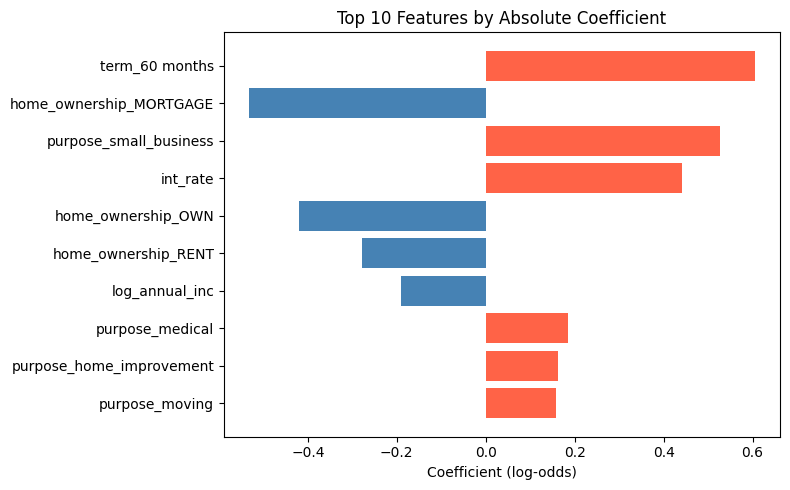

In [14]:
base_pipe = get_base_pipeline(trained[FINAL_MODEL_NAME]['model'])
preprocessor_fitted = base_pipe.named_steps['preprocessor']
lr_model = base_pipe.named_steps['model']

num_names = list(NUM_COLS)
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_names = list(cat_encoder.get_feature_names_out(CAT_COLS))
all_names = num_names + cat_names

coef_df = (
    pd.DataFrame({
        'feature': all_names,
        'coefficient': lr_model.coef_[0],
    })
    .sort_values('coefficient', key=lambda s: s.abs(), ascending=False)
)

print('=== LOGISTIC REGRESSION COEFFICIENTS ===\n')
print(coef_df.to_string(index=False))

coef_df.to_csv(BUILD_DIR / 'lr_coefficients.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
top = coef_df.head(10).copy()
colors = ['tomato' if c > 0 else 'steelblue' for c in top['coefficient']]

ax.barh(range(len(top)), top['coefficient'].values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'].values)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 10 Features by Absolute Coefficient')
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration curves

Calibration curves compare predicted probability against observed default frequency. The diagonal line is perfect calibration. ECE is shown in each panel using the fixed-bin definition above.

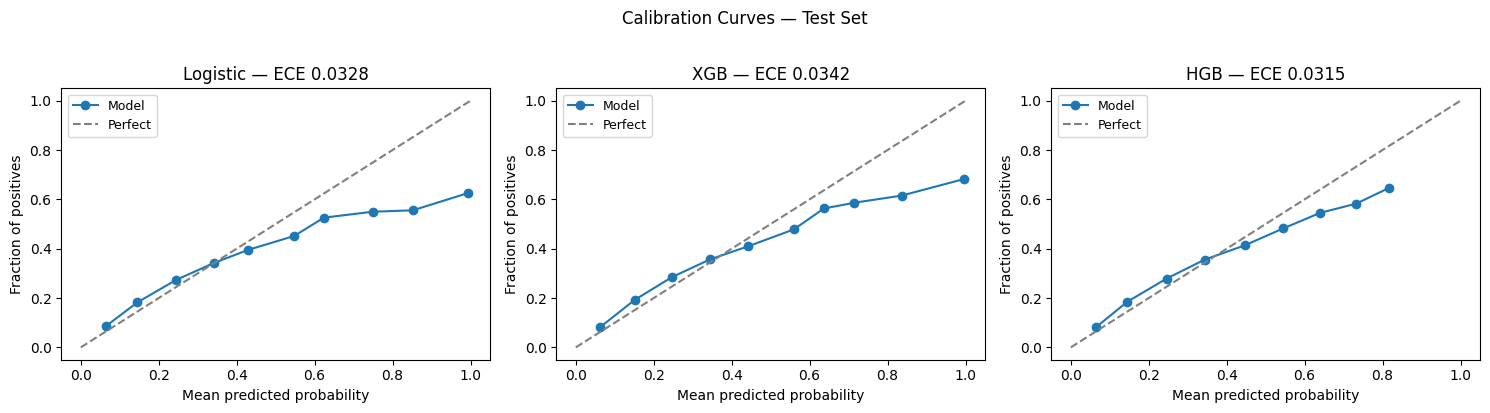

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, d) in zip(axes, trained.items()):
    prob_true, prob_pred = calibration_curve(
        y_test,
        d['probs_test'],
        n_bins=10,
        strategy='uniform',
    )
    ece = compute_ece(y_test.values, d['probs_test'])

    ax.plot(prob_pred, prob_true, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
    ax.set_title(f'{name} — ECE {ece:.4f}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=9)

fig.suptitle('Calibration Curves — Test Set', y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## ECE by difficulty tier

This checks whether calibration quality is similar across the experimental difficulty tiers constructed in EDA. The final model is evaluated by tier using test-set cases only.

In [16]:
test_with_diff = test[['case_id', 'difficulty_tier']].copy()
test_with_diff['pred_prob'] = final_probs
test_with_diff['y_true'] = y_test.values

print('=== ECE BY DIFFICULTY TIER ===\n')

for tier in ['easy', 'medium', 'hard']:
    mask = test_with_diff['difficulty_tier'] == tier
    sub_y = test_with_diff.loc[mask, 'y_true'].values
    sub_p = test_with_diff.loc[mask, 'pred_prob'].values

    if len(sub_y) == 0:
        print(f'{tier:8s}: no rows')
        continue

    ece = compute_ece(sub_y, sub_p)
    brier = brier_score_loss(sub_y, sub_p)

    print(f'{tier:8s}: ECE={ece:.4f}, Brier={brier:.4f}, n={mask.sum():,}')

=== ECE BY DIFFICULTY TIER ===

easy    : ECE=0.0248, Brier=0.1155, n=241,081
medium  : ECE=0.0399, Brier=0.2032, n=175,439
hard    : ECE=0.0496, Brier=0.2391, n=63,224


## Probability distribution

The distribution of predicted probabilities shows the decision environment created for the DSS experiment. If probabilities are concentrated in a relatively narrow range, cases are less trivially separable and participants must reason under uncertainty.

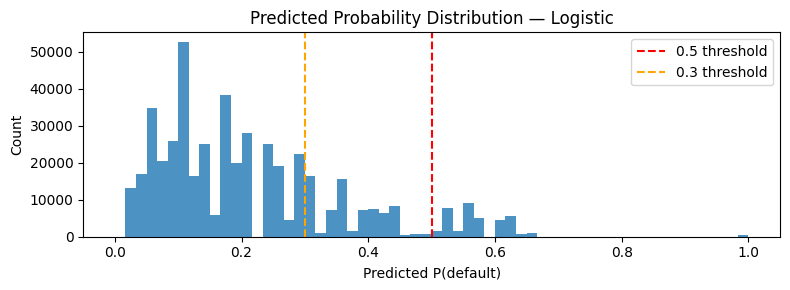

=== PROBABILITY DISTRIBUTION DIAGNOSTICS ===

Sharpness variance       : 0.0224
Mean predicted P(default): 0.2151
Actual default rate      : 0.2288
Calibration gap mean     : 0.0137

Fraction predicted > 0.5 : 0.0783
Fraction predicted > 0.3 : 0.2307
Fraction predicted > 0.2 : 0.4377

Prediction range distribution:
0–0.1   :  111,420 (23.2%)
0.1–0.2 :  158,317 (33.0%)
0.2–0.3 :   99,331 (20.7%)
0.3–0.4 :   49,041 (10.2%)
0.4–0.5 :   24,095 (5.0%)
0.5–0.6 :   24,975 (5.2%)
0.6+    :   12,565 (2.6%)


In [17]:
probs_arr = np.asarray(final_probs)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(probs_arr, bins=60, edgecolor='none', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.axvline(0.3, color='orange', linestyle='--', label='0.3 threshold')
ax.set_title(f'Predicted Probability Distribution — {FINAL_MODEL_NAME}')
ax.set_xlabel('Predicted P(default)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
fig.savefig(FIGS_DIR / 'prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== PROBABILITY DISTRIBUTION DIAGNOSTICS ===\n')
print(f'Sharpness variance       : {np.var(probs_arr):.4f}')
print(f'Mean predicted P(default): {probs_arr.mean():.4f}')
print(f'Actual default rate      : {y_test.mean():.4f}')
print(f'Calibration gap mean     : {abs(probs_arr.mean() - y_test.mean()):.4f}')

print(f'\nFraction predicted > 0.5 : {(probs_arr > 0.5).mean():.4f}')
print(f'Fraction predicted > 0.3 : {(probs_arr > 0.3).mean():.4f}')
print(f'Fraction predicted > 0.2 : {(probs_arr > 0.2).mean():.4f}')

bins_diag = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 1.0]
labels_diag = ['0–0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5', '0.5–0.6', '0.6+']

counts = (
    pd.cut(probs_arr, bins=bins_diag, labels=labels_diag, include_lowest=True)
    .value_counts()
    .sort_index()
)

print('\nPrediction range distribution:')
for label, count in counts.items():
    print(f'{label:8s}: {count:>8,} ({count / len(probs_arr) * 100:.1f}%)')

### Interpretation: probability compression

The final model may produce low-variance probabilities concentrated in a moderate risk band. This is not automatically a flaw for the experiment. It creates a low-signal decision environment where cases are not trivially separable, increasing the relevance of probabilistic reasoning and human-AI interaction structure.

## Feature distribution shift

This diagnostic compares key feature distributions between the pre-2016 training period and the post-2016 test period. Distribution shift motivates calibrated probabilities and cautions against relying on a single hard threshold.

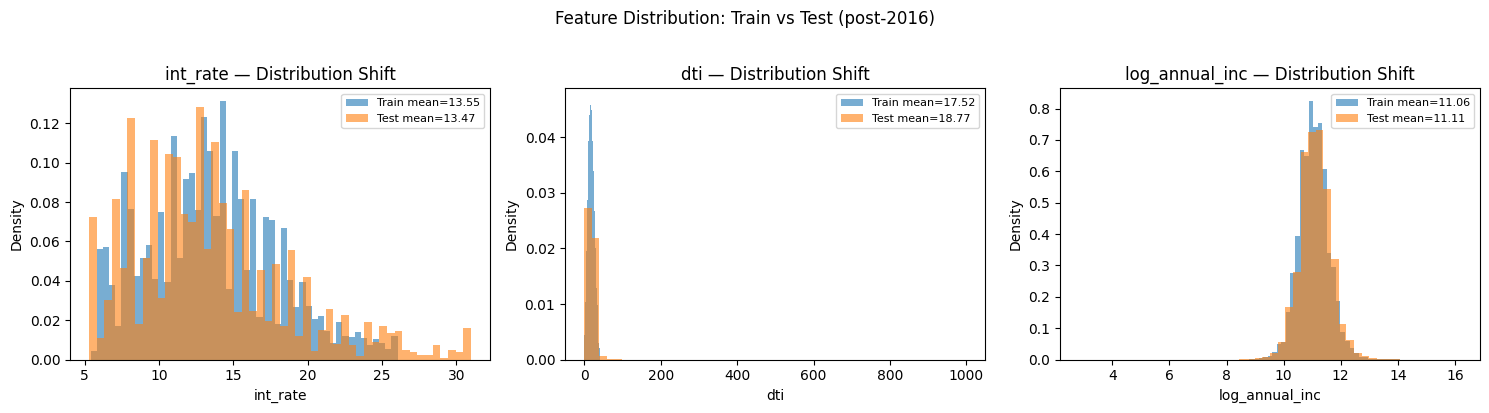

=== FEATURE DISTRIBUTION SHIFT ===

int_rate             train mean=13.548 test mean=13.467 delta=-0.081
dti                  train mean=17.524 test mean=18.766 delta=+1.242
log_annual_inc       train mean=11.058 test mean=11.115 delta=+0.056


In [18]:
shift_features = ['int_rate', 'dti', 'log_annual_inc']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, shift_features):
    ax.hist(
        train[col].dropna(),
        bins=50,
        alpha=0.6,
        density=True,
        label=f'Train mean={train[col].mean():.2f}',
    )
    ax.hist(
        test[col].dropna(),
        bins=50,
        alpha=0.6,
        density=True,
        label=f'Test mean={test[col].mean():.2f}',
    )
    ax.set_title(f'{col} — Distribution Shift')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distribution: Train vs Test (post-2016)', y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'feature_shift.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== FEATURE DISTRIBUTION SHIFT ===\n')
for col in shift_features:
    delta = test[col].mean() - train[col].mean()
    print(
        f'{col:20s} '
        f'train mean={train[col].mean():.3f} '
        f'test mean={test[col].mean():.3f} '
        f'delta={delta:+.3f}'
    )

A moderate feature distribution shift, especially in DTI or interest rate, indicates mild covariate shift between training and test periods. This further supports using calibrated probabilities rather than threshold-only decisions.

## Export candidate pool

The candidate pool is the official scored post-2016 set used downstream for case selection.

Exported fields include:

- `case_id`: deterministic identifier from the processed dataset
- final modeling features
- `y_true`: observed default outcome
- `pred_prob`: final model predicted default probability
- `difficulty_score` and `difficulty_tier`: EDA-derived fields used for experimental case design

The export is sorted deterministically by `case_id` and validated before writing.

In [ ]:
FEATURES_ORDER = list(X_test.columns)

candidate_pool = X_test.copy()
candidate_pool['case_id'] = case_id_test.values
candidate_pool['y_true'] = y_test.values
candidate_pool['pred_prob'] = final_probs

candidate_pool = candidate_pool.merge(
    test[['case_id', 'difficulty_score', 'difficulty_tier']],
    on='case_id',
    how='left',
)

candidate_pool = candidate_pool[
    ['case_id', *FEATURES_ORDER, 'y_true', 'pred_prob', 'difficulty_score', 'difficulty_tier']
]

# Deterministic sort
candidate_pool = candidate_pool.sort_values('case_id').reset_index(drop=True)

# Validation checks
required_cols = ['case_id', 'y_true', 'pred_prob', 'difficulty_score', 'difficulty_tier']
missing_cols = [c for c in required_cols if c not in candidate_pool.columns]
assert not missing_cols, f'Missing required columns: {missing_cols}'

assert candidate_pool['case_id'].is_unique, (
    f"Duplicate case_id values: {candidate_pool['case_id'].duplicated().sum()}"
)

assert candidate_pool['pred_prob'].between(0, 1).all(), (
    f"pred_prob out of [0,1]: "
    f"min={candidate_pool['pred_prob'].min():.4f}, "
    f"max={candidate_pool['pred_prob'].max():.4f}"
)

assert not candidate_pool['difficulty_score'].isna().any(), (
    f"Missing difficulty_score: {candidate_pool['difficulty_score'].isna().sum()}"
)

assert not candidate_pool['difficulty_tier'].isna().any(), (
    f"Missing difficulty_tier: {candidate_pool['difficulty_tier'].isna().sum()}"
)

out_path = BUILD_DIR / 'candidate_pool_scored.parquet'
candidate_pool.to_parquet(out_path, index=False)

print('All validation checks passed')
print('Saved:', out_path)
print('Shape:', candidate_pool.shape)

All validation checks passed
Saved: /Users/annaasatryan/Desktop/capstone/artifacts/build/candidate_pool_scored.parquet
Shape: (479744, 14)
